[← Back to Overview](./00_overview.ipynb) | [Next: Survival Analysis →](./02_survival_analysis.ipynb)

# TCGA-BRCA Clinical Data Analysis

Detailed analysis of clinical and demographic data for TCGA Breast Cancer patients.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

from oncolearn.api.xenabrowser import XenaCohortBuilder

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Clinical Data

Using the `XenaCohort` class, we can load all clinical datasets with one simple method call.
This automatically merges data from multiple sources:
- PAM50 subtype classification
- Clinical and demographic data
- Survival data

In [3]:
# Build the cohort
builder = XenaCohortBuilder()
cohort = builder.build_cohort("BRCA")

# Load clinical data
clinical = cohort.clinical()

Deduplicated brca/pam50: 141 -> 74 rows


In [4]:
# Display basic information about the loaded data
print(f"✓ Clinical data loaded successfully")
print(f"  Shape: {clinical.shape[0]:,} samples × {clinical.shape[1]:,} features")
print(f"\nFirst few columns: {clinical.columns.tolist()[:5]}")
print(f"\nDataFrame info:")
clinical.info(verbose=False)

✓ Clinical data loaded successfully
  Shape: 1,257 samples × 89 features

First few columns: ['sample', 'PAM50', 'id', 'disease_type', 'case_id']

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Columns: 89 entries, sample to _PATIENT
dtypes: float64(17), object(72)
memory usage: 874.1+ KB


In [5]:
# Group clinical columns by category
column_categories = {
    'demographic': [col for col in clinical.columns if 'demographic' in col],
    'diagnoses': [col for col in clinical.columns if 'diagnoses' in col],
    'treatments': [col for col in clinical.columns if 'treatments' in col],
    'samples': [col for col in clinical.columns if 'samples' in col],
    'project': [col for col in clinical.columns if 'project' in col],
    'annotations': [col for col in clinical.columns if 'annotations' in col],
}

for category, cols in column_categories.items():
    print(f"\n{category.upper()} ({len(cols)} columns):")
    for col in cols[:10]:
        print(f"  - {col}")


DEMOGRAPHIC (9 columns):
  - race.demographic
  - gender.demographic
  - ethnicity.demographic
  - vital_status.demographic
  - age_at_index.demographic
  - days_to_birth.demographic
  - year_of_birth.demographic
  - year_of_death.demographic
  - days_to_death.demographic

DIAGNOSES (30 columns):
  - synchronous_malignancy.diagnoses
  - ajcc_pathologic_stage.diagnoses
  - days_to_diagnosis.diagnoses
  - last_known_disease_status.diagnoses
  - tissue_or_organ_of_origin.diagnoses
  - days_to_last_follow_up.diagnoses
  - age_at_diagnosis.diagnoses
  - primary_diagnosis.diagnoses
  - prior_malignancy.diagnoses
  - year_of_diagnosis.diagnoses

TREATMENTS (7 columns):
  - treatment_id.treatments.diagnoses
  - submitter_id.treatments.diagnoses
  - treatment_type.treatments.diagnoses
  - treatment_or_therapy.treatments.diagnoses
  - created_datetime.treatments.diagnoses
  - updated_datetime.treatments.diagnoses
  - state.treatments.diagnoses

SAMPLES (15 columns):
  - sample_type_id.samples
 

## Column Overview

In [6]:
# Display dataset information
print(f"Clinical Data Overview")
print(f"{'='*60}")
print(f"Total rows: {clinical.shape[0]:,}")
print(f"Total columns: {clinical.shape[1]:,}")
print(f"\nMemory usage: {clinical.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Count columns by category
categories = {
    'demographic': len([c for c in clinical.columns if 'demographic' in c]),
    'diagnoses': len([c for c in clinical.columns if 'diagnoses' in c]),
    'treatments': len([c for c in clinical.columns if 'treatment' in c.lower()]),
    'samples': len([c for c in clinical.columns if 'samples' in c]),
    'project': len([c for c in clinical.columns if 'project' in c]),
    'annotations': len([c for c in clinical.columns if 'annotations' in c]),
    'other': 0
}

# Calculate "other" category
categories['other'] = clinical.shape[1] - sum(categories.values())

print(f"\nColumns by category:")
for category, count in categories.items():
    if count > 0:
        pct = (count / clinical.shape[1]) * 100
        print(f"  {category.capitalize():15s}: {count:4d} ({pct:5.1f}%)")

Clinical Data Overview
Total rows: 1,257
Total columns: 89

Memory usage: 5.50 MB

Columns by category:
  Demographic    :    9 ( 10.1%)
  Diagnoses      :   30 ( 33.7%)
  Treatments     :    8 (  9.0%)
  Samples        :   15 ( 16.9%)
  Project        :    6 (  6.7%)
  Annotations    :   15 ( 16.9%)
  Other          :    6 (  6.7%)


## Demographics Analysis

In [7]:
# Key demographic features
demo_features = [
    'gender.demographic',
    'race.demographic',
    'ethnicity.demographic',
    'vital_status.demographic',
    'age_at_index.demographic',
    'days_to_birth.demographic',
    'year_of_birth.demographic'
]

available_demo = [f for f in demo_features if f in clinical.columns]
print(f"Available demographic features: {len(available_demo)}")

# Missing data summary
print("\nMissing data:")
for feature in available_demo:
    missing_pct = (clinical[feature].isna().sum() / len(clinical)) * 100
    unique_vals = clinical[feature].nunique()
    print(f"{feature:40s}: {missing_pct:5.1f}% missing, {unique_vals:4d} unique values")

Available demographic features: 7

Missing data:
gender.demographic                      :   0.2% missing,    2 unique values
race.demographic                        :   0.2% missing,    5 unique values
ethnicity.demographic                   :   0.2% missing,    3 unique values
vital_status.demographic                :   0.2% missing,    2 unique values
age_at_index.demographic                :   0.2% missing,   65 unique values
days_to_birth.demographic               :   1.5% missing, 1044 unique values
year_of_birth.demographic               :   0.5% missing,   73 unique values


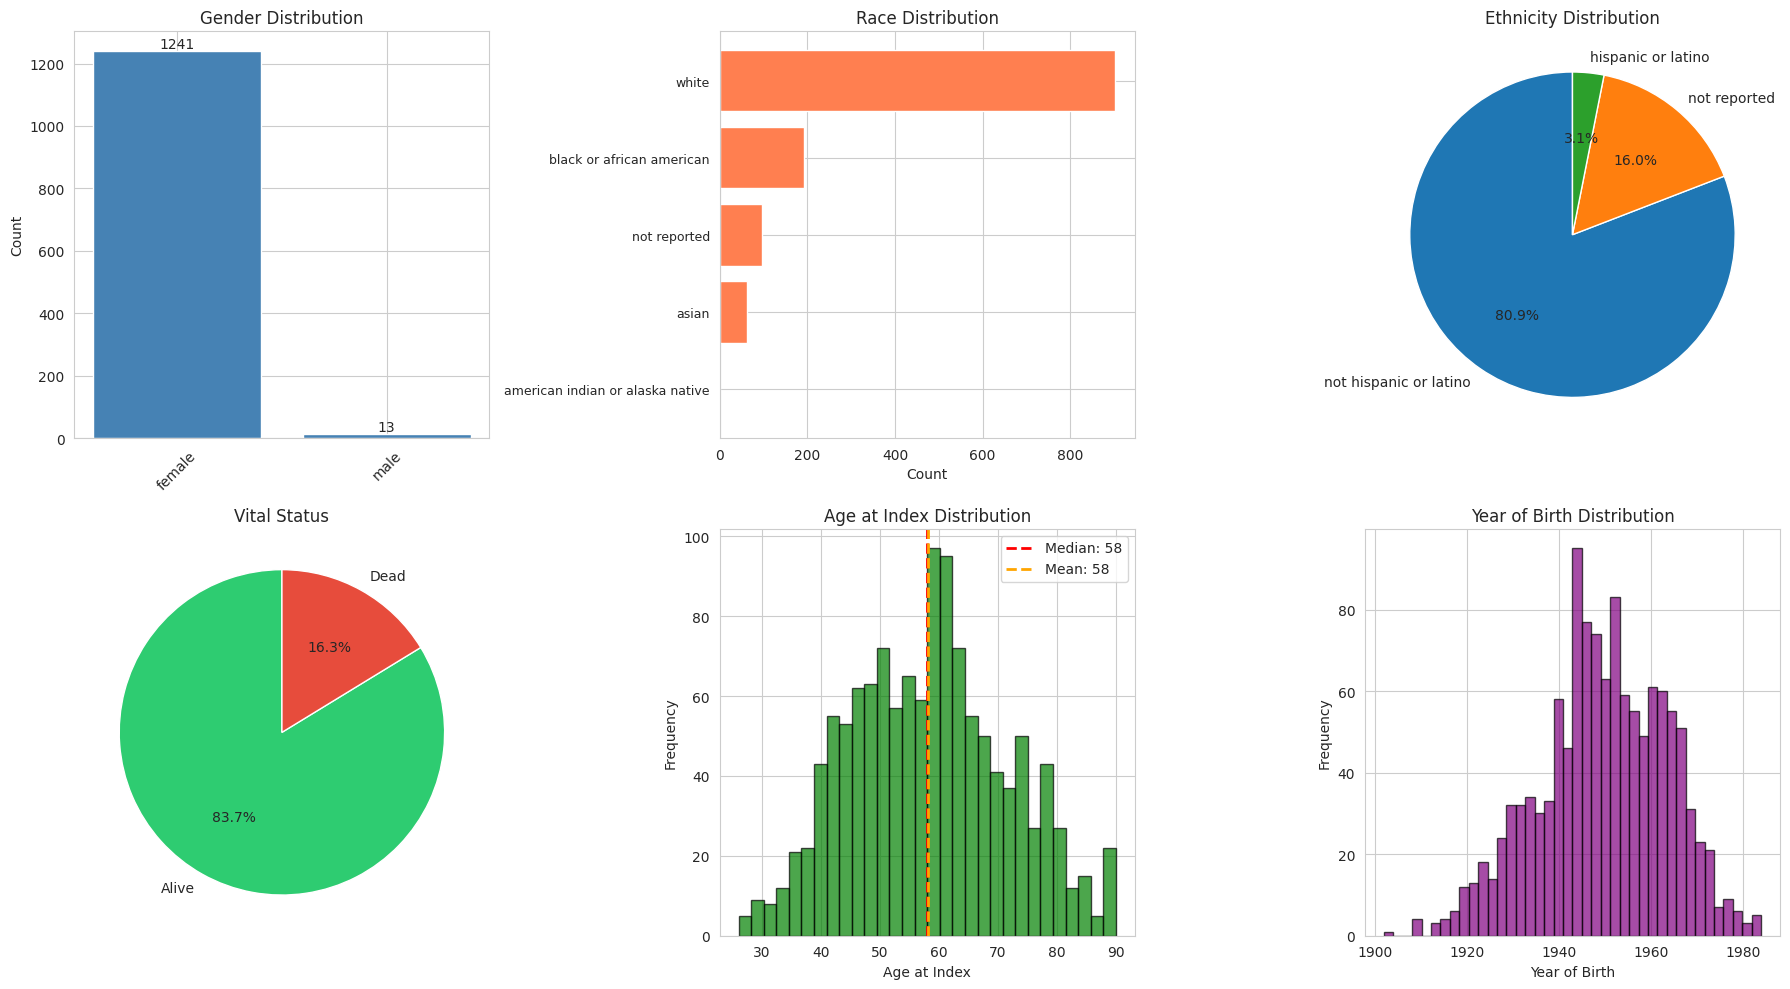

In [8]:
# Visualize demographics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Gender
if 'gender.demographic' in clinical.columns:
    gender_counts = clinical['gender.demographic'].value_counts()
    axes[0].bar(range(len(gender_counts)),
                gender_counts.values, color='steelblue')
    axes[0].set_xticks(range(len(gender_counts)))
    axes[0].set_xticklabels(gender_counts.index, rotation=45)
    axes[0].set_title('Gender Distribution')
    axes[0].set_ylabel('Count')
    for i, v in enumerate(gender_counts.values):
        axes[0].text(i, v + 10, str(v), ha='center')

# Race
if 'race.demographic' in clinical.columns:
    race_counts = clinical['race.demographic'].value_counts().head(8)
    axes[1].barh(range(len(race_counts)), race_counts.values, color='coral')
    axes[1].set_yticks(range(len(race_counts)))
    axes[1].set_yticklabels(race_counts.index, fontsize=9)
    axes[1].set_xlabel('Count')
    axes[1].set_title('Race Distribution')
    axes[1].invert_yaxis()

# Ethnicity
if 'ethnicity.demographic' in clinical.columns:
    eth_counts = clinical['ethnicity.demographic'].value_counts()
    axes[2].pie(eth_counts.values, labels=eth_counts.index,
                autopct='%1.1f%%', startangle=90)
    axes[2].set_title('Ethnicity Distribution')

# Vital status
if 'vital_status.demographic' in clinical.columns:
    vital_counts = clinical['vital_status.demographic'].value_counts()
    colors = ['#2ecc71', '#e74c3c'] if len(vital_counts) == 2 else None
    axes[3].pie(vital_counts.values, labels=vital_counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[3].set_title('Vital Status')

# Age at index
if 'age_at_index.demographic' in clinical.columns:
    age_data = pd.to_numeric(
        clinical['age_at_index.demographic'], errors='coerce').dropna()
    axes[4].hist(age_data, bins=30, color='green',
                 alpha=0.7, edgecolor='black')
    axes[4].axvline(age_data.median(), color='red', linestyle='--', linewidth=2,
                    label=f'Median: {age_data.median():.0f}')
    axes[4].axvline(age_data.mean(), color='orange', linestyle='--', linewidth=2,
                    label=f'Mean: {age_data.mean():.0f}')
    axes[4].set_xlabel('Age at Index')
    axes[4].set_ylabel('Frequency')
    axes[4].set_title('Age at Index Distribution')
    axes[4].legend()

# Year of birth
if 'year_of_birth.demographic' in clinical.columns:
    yob_data = pd.to_numeric(
        clinical['year_of_birth.demographic'], errors='coerce').dropna()
    axes[5].hist(yob_data, bins=40, color='purple',
                 alpha=0.7, edgecolor='black')
    axes[5].set_xlabel('Year of Birth')
    axes[5].set_ylabel('Frequency')
    axes[5].set_title('Year of Birth Distribution')

plt.tight_layout()
plt.show()

## Diagnosis Information

In [9]:
# Key diagnosis features
diag_features = [
    'primary_diagnosis.diagnoses',
    'ajcc_pathologic_stage.diagnoses',
    'ajcc_pathologic_t.diagnoses',
    'ajcc_pathologic_n.diagnoses',
    'ajcc_pathologic_m.diagnoses',
    'tumor_grade.diagnoses',
    'morphology.diagnoses',
    'tissue_or_organ_of_origin.diagnoses',
    'age_at_diagnosis.diagnoses',
    'days_to_diagnosis.diagnoses',
    'year_of_diagnosis.diagnoses',
    'prior_malignancy.diagnoses',
    'synchronous_malignancy.diagnoses',
    'progression_or_recurrence.diagnoses'
]

available_diag = [f for f in diag_features if f in clinical.columns]
print(f"Available diagnosis features: {len(available_diag)}")

print("\nMissing data:")
for feature in available_diag:
    missing_pct = (clinical[feature].isna().sum() / len(clinical)) * 100
    unique_vals = clinical[feature].nunique()
    print(f"{feature:50s}: {missing_pct:5.1f}% missing, {unique_vals:4d} unique")

Available diagnosis features: 14

Missing data:
primary_diagnosis.diagnoses                       :   0.2% missing,   22 unique
ajcc_pathologic_stage.diagnoses                   :   1.2% missing,   12 unique
ajcc_pathologic_t.diagnoses                       :   0.2% missing,   13 unique
ajcc_pathologic_n.diagnoses                       :   0.2% missing,   16 unique
ajcc_pathologic_m.diagnoses                       :   0.2% missing,    4 unique
tumor_grade.diagnoses                             :   0.2% missing,    1 unique
morphology.diagnoses                              :   0.2% missing,   22 unique
tissue_or_organ_of_origin.diagnoses               :   0.2% missing,    6 unique
age_at_diagnosis.diagnoses                        :   1.5% missing, 1044 unique
days_to_diagnosis.diagnoses                       :   0.2% missing,    1 unique
year_of_diagnosis.diagnoses                       :   0.4% missing,   26 unique
prior_malignancy.diagnoses                        :   0.2% missing,    3

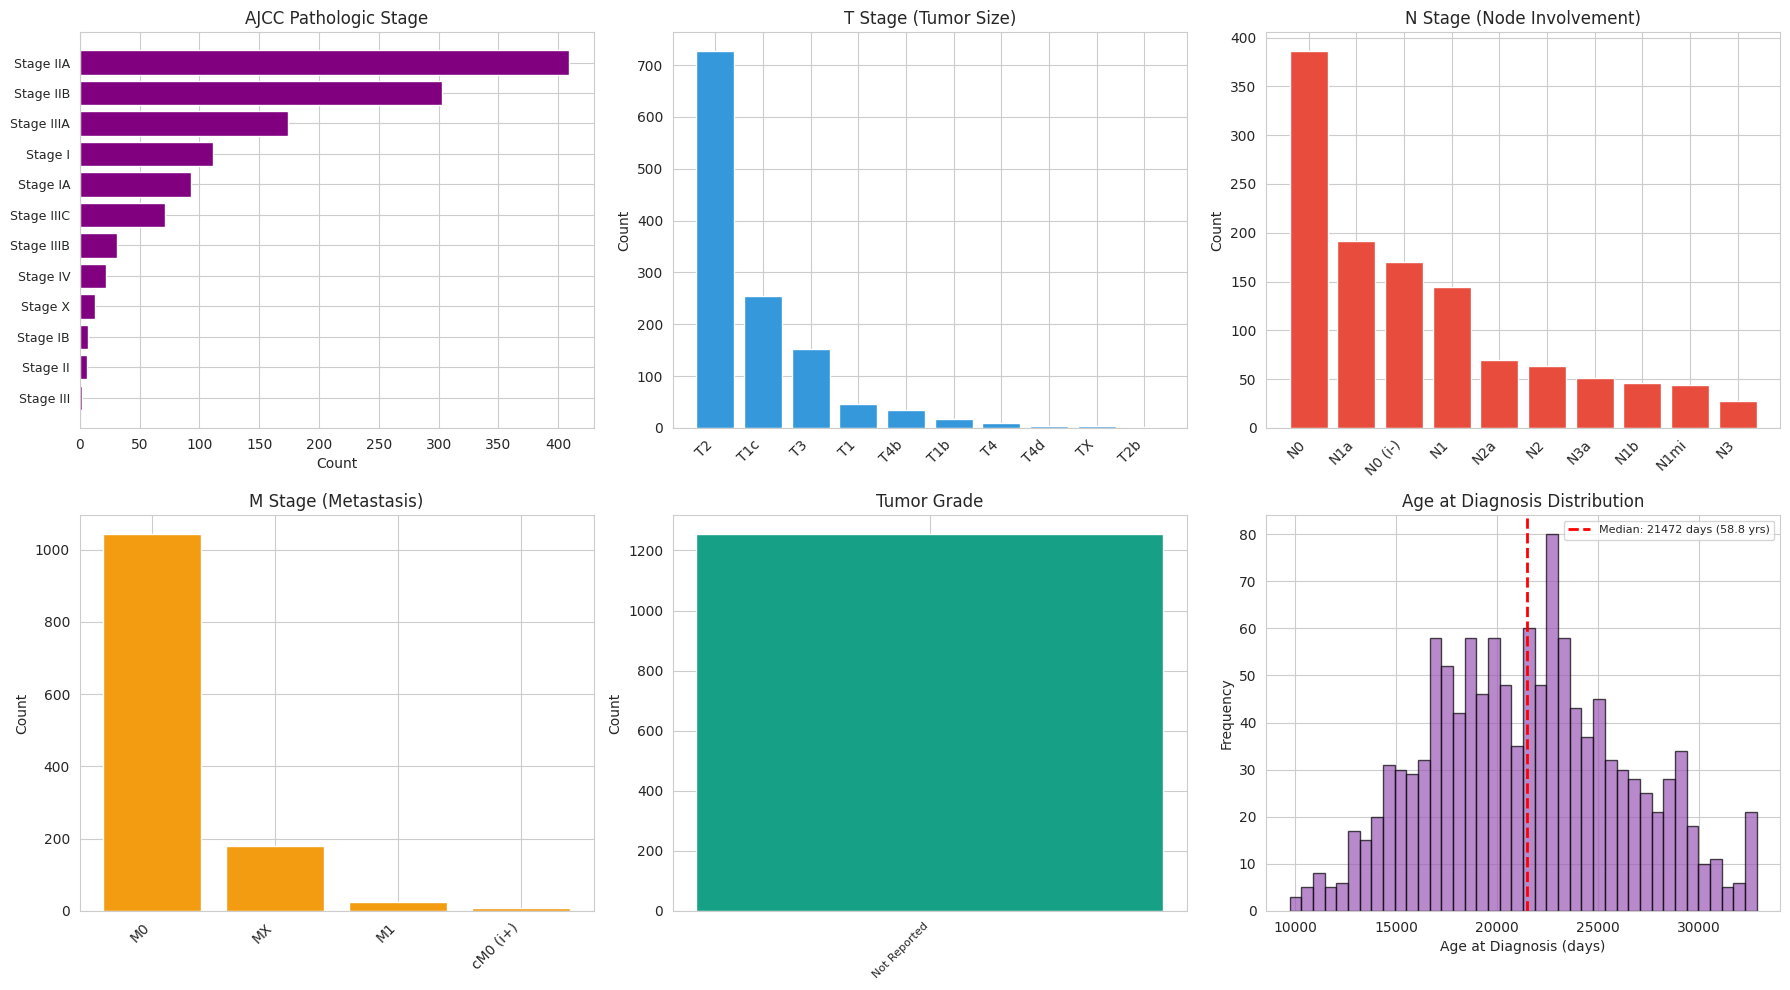

In [10]:
# Tumor staging and grading
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# AJCC Pathologic Stage
if 'ajcc_pathologic_stage.diagnoses' in clinical.columns:
    stage_counts = clinical['ajcc_pathologic_stage.diagnoses'].value_counts().head(
        12)
    axes[0].barh(range(len(stage_counts)), stage_counts.values, color='purple')
    axes[0].set_yticks(range(len(stage_counts)))
    axes[0].set_yticklabels(stage_counts.index, fontsize=9)
    axes[0].set_xlabel('Count')
    axes[0].set_title('AJCC Pathologic Stage')
    axes[0].invert_yaxis()

# T stage
if 'ajcc_pathologic_t.diagnoses' in clinical.columns:
    t_counts = clinical['ajcc_pathologic_t.diagnoses'].value_counts().head(10)
    axes[1].bar(range(len(t_counts)), t_counts.values, color='#3498db')
    axes[1].set_xticks(range(len(t_counts)))
    axes[1].set_xticklabels(t_counts.index, rotation=45, ha='right')
    axes[1].set_ylabel('Count')
    axes[1].set_title('T Stage (Tumor Size)')

# N stage
if 'ajcc_pathologic_n.diagnoses' in clinical.columns:
    n_counts = clinical['ajcc_pathologic_n.diagnoses'].value_counts().head(10)
    axes[2].bar(range(len(n_counts)), n_counts.values, color='#e74c3c')
    axes[2].set_xticks(range(len(n_counts)))
    axes[2].set_xticklabels(n_counts.index, rotation=45, ha='right')
    axes[2].set_ylabel('Count')
    axes[2].set_title('N Stage (Node Involvement)')

# M stage
if 'ajcc_pathologic_m.diagnoses' in clinical.columns:
    m_counts = clinical['ajcc_pathologic_m.diagnoses'].value_counts()
    axes[3].bar(range(len(m_counts)), m_counts.values, color='#f39c12')
    axes[3].set_xticks(range(len(m_counts)))
    axes[3].set_xticklabels(m_counts.index, rotation=45, ha='right')
    axes[3].set_ylabel('Count')
    axes[3].set_title('M Stage (Metastasis)')

# Tumor grade
if 'tumor_grade.diagnoses' in clinical.columns:
    grade_counts = clinical['tumor_grade.diagnoses'].value_counts()
    axes[4].bar(range(len(grade_counts)), grade_counts.values, color='#16a085')
    axes[4].set_xticks(range(len(grade_counts)))
    axes[4].set_xticklabels(
        grade_counts.index, rotation=45, ha='right', fontsize=8)
    axes[4].set_ylabel('Count')
    axes[4].set_title('Tumor Grade')

# Age at diagnosis
if 'age_at_diagnosis.diagnoses' in clinical.columns:
    age_diag = pd.to_numeric(
        clinical['age_at_diagnosis.diagnoses'], errors='coerce').dropna()
    axes[5].hist(age_diag, bins=40, color='#9b59b6',
                 alpha=0.7, edgecolor='black')
    axes[5].axvline(age_diag.median(), color='red', linestyle='--', linewidth=2,
                    label=f'Median: {age_diag.median():.0f} days ({age_diag.median()/365.25:.1f} yrs)')
    axes[5].set_xlabel('Age at Diagnosis (days)')
    axes[5].set_ylabel('Frequency')
    axes[5].set_title('Age at Diagnosis Distribution')
    axes[5].legend(fontsize=8)

plt.tight_layout()
plt.show()

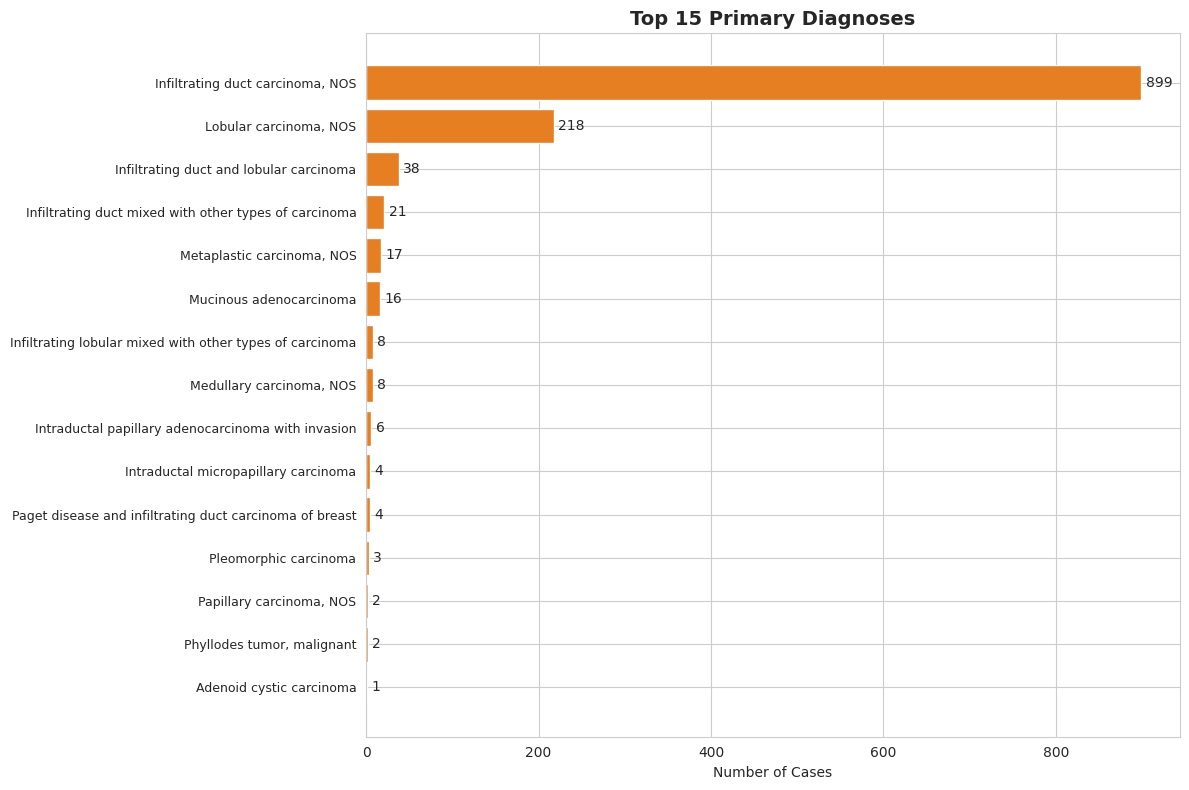


Total unique primary diagnoses: 22


In [11]:
# Primary diagnosis distribution
if 'primary_diagnosis.diagnoses' in clinical.columns:
    primary_diag = clinical['primary_diagnosis.diagnoses'].value_counts().head(
        15)

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(primary_diag)), primary_diag.values, color='#e67e22')
    plt.yticks(range(len(primary_diag)), primary_diag.index, fontsize=9)
    plt.xlabel('Number of Cases')
    plt.title('Top 15 Primary Diagnoses', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

    # Add value labels
    for i, v in enumerate(primary_diag.values):
        plt.text(v + 5, i, str(v), va='center')

    plt.tight_layout()
    plt.show()

    print(
        f"\nTotal unique primary diagnoses: {clinical['primary_diagnosis.diagnoses'].nunique()}")

## Treatment Information

In [12]:
# Treatment features
treatment_cols = [
    col for col in clinical.columns if 'treatment' in col.lower()]
print(f"Treatment-related columns: {len(treatment_cols)}")
print("\nSample treatment columns:")
for col in treatment_cols[:15]:
    print(f"  - {col}")

# Check for prior treatment
if 'prior_treatment.diagnoses' in clinical.columns:
    print("\nPrior Treatment:")
    print(clinical['prior_treatment.diagnoses'].value_counts())

# Check treatment types
treatment_type_cols = [
    col for col in clinical.columns if 'treatment_type' in col.lower()]
if treatment_type_cols:
    print(f"\nTreatment type columns found: {len(treatment_type_cols)}")

Treatment-related columns: 8

Sample treatment columns:
  - prior_treatment.diagnoses
  - treatment_id.treatments.diagnoses
  - submitter_id.treatments.diagnoses
  - treatment_type.treatments.diagnoses
  - treatment_or_therapy.treatments.diagnoses
  - created_datetime.treatments.diagnoses
  - updated_datetime.treatments.diagnoses
  - state.treatments.diagnoses

Prior Treatment:
prior_treatment.diagnoses
No              1238
Yes               14
Not Reported       2
Name: count, dtype: int64

Treatment type columns found: 1


## Sample Information

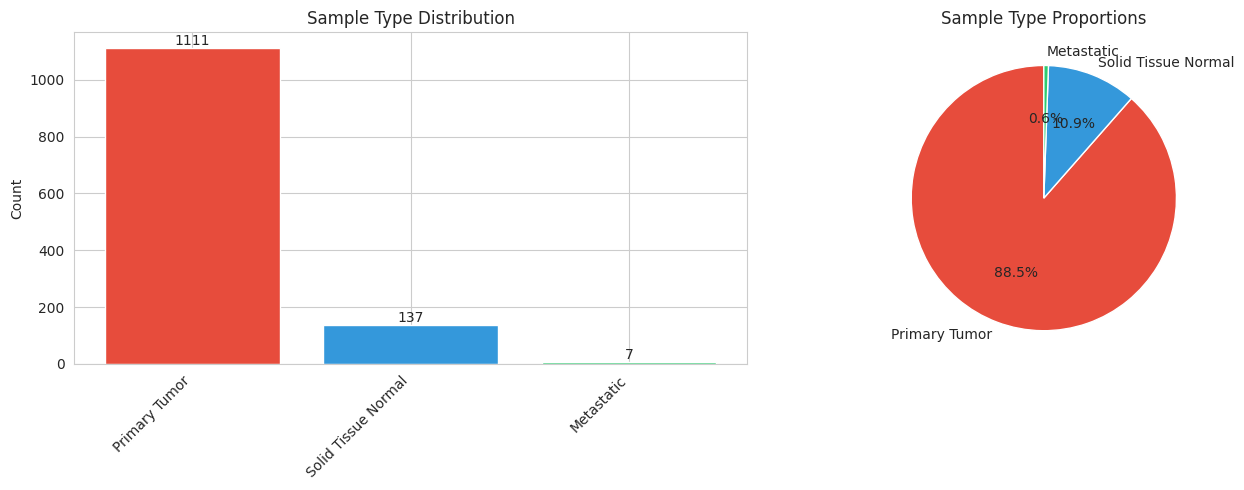


Sample Type Distribution:
sample_type.samples
Primary Tumor          1111
Solid Tissue Normal     137
Metastatic                7
Name: count, dtype: int64


In [13]:
# Sample type distribution
if 'sample_type.samples' in clinical.columns:
    sample_types = clinical['sample_type.samples'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    axes[0].bar(range(len(sample_types)), sample_types.values,
                color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][:len(sample_types)])
    axes[0].set_xticks(range(len(sample_types)))
    axes[0].set_xticklabels(sample_types.index, rotation=45, ha='right')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Sample Type Distribution')
    for i, v in enumerate(sample_types.values):
        axes[0].text(i, v + 10, str(v), ha='center')

    # Pie chart
    axes[1].pie(sample_types.values, labels=sample_types.index, autopct='%1.1f%%',
                colors=['#e74c3c', '#3498db', '#2ecc71',
                        '#f39c12'][:len(sample_types)],
                startangle=90)
    axes[1].set_title('Sample Type Proportions')

    plt.tight_layout()
    plt.show()

    print("\nSample Type Distribution:")
    print(sample_types)

In [14]:
# Additional sample characteristics
sample_features = [
    'tumor_descriptor.samples',
    'composition.samples',
    'tissue_type.samples',
    'is_ffpe.samples',
    'preservation_method.samples'
]

for feature in sample_features:
    if feature in clinical.columns:
        print(f"\n{feature}:")
        print(clinical[feature].value_counts())


tumor_descriptor.samples:
tumor_descriptor.samples
Primary           1111
Not Applicable     137
Metastatic           7
Name: count, dtype: int64

composition.samples:
composition.samples
Not Reported    1254
Name: count, dtype: int64

tissue_type.samples:
tissue_type.samples
Tumor     1118
Normal     137
Name: count, dtype: int64

is_ffpe.samples:
is_ffpe.samples
False    1243
True       12
Name: count, dtype: int64

preservation_method.samples:
preservation_method.samples
OCT        764
Unknown    475
FFPE        16
Name: count, dtype: int64


## Cross-tabulations and Relationships

Stage by Sample Type:
sample_type.samples              Metastatic  Primary Tumor  \
ajcc_pathologic_stage.diagnoses                              
Stage I                                   0             90   
Stage IA                                  0             89   
Stage IB                                  0              7   
Stage II                                  0              6   
Stage IIA                                 1            363   
Stage IIB                                 4            261   
Stage III                                 0              2   
Stage IIIA                                0            156   
Stage IIIB                                0             27   
Stage IIIC                                2             65   

sample_type.samples              Solid Tissue Normal  
ajcc_pathologic_stage.diagnoses                       
Stage I                                           21  
Stage IA                                           4  
Stage IB     

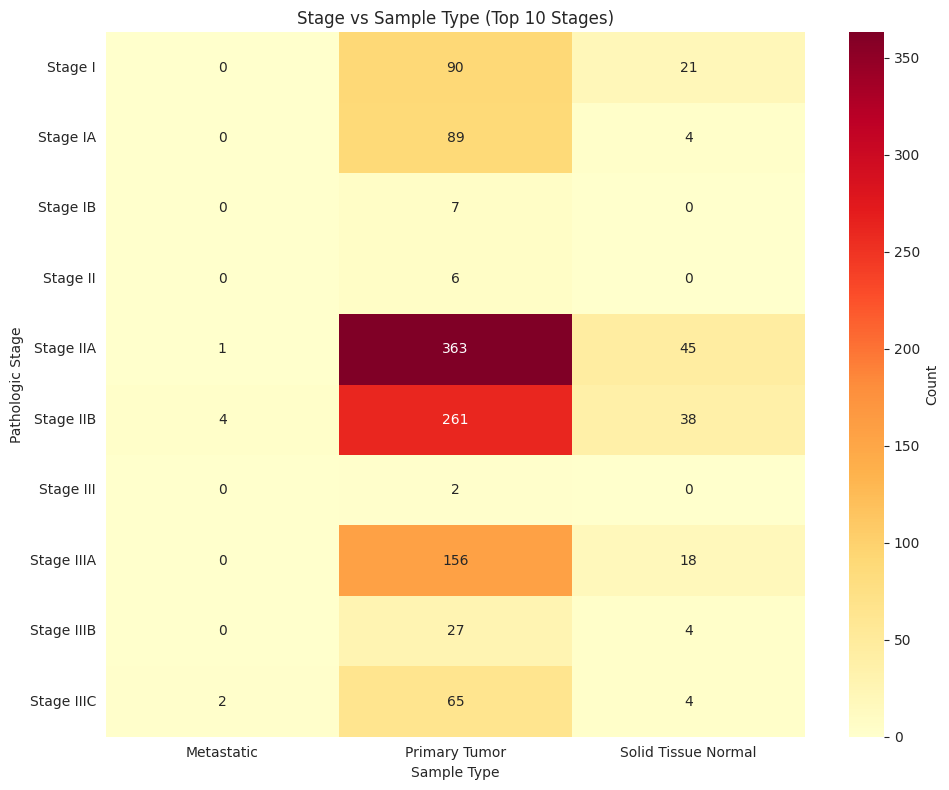

In [15]:
# Stage by sample type
if 'ajcc_pathologic_stage.diagnoses' in clinical.columns and 'sample_type.samples' in clinical.columns:
    stage_sample_ct = pd.crosstab(
        clinical['ajcc_pathologic_stage.diagnoses'],
        clinical['sample_type.samples']
    )

    print("Stage by Sample Type:")
    print(stage_sample_ct.head(10))

    # Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(stage_sample_ct.iloc[:10], annot=True,
                fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
    plt.title('Stage vs Sample Type (Top 10 Stages)')
    plt.xlabel('Sample Type')
    plt.ylabel('Pathologic Stage')
    plt.tight_layout()
    plt.show()


Vital Status by Stage (% within each stage):
vital_status.demographic         Alive   Dead
ajcc_pathologic_stage.diagnoses              
Stage I                           81.1   18.9
Stage IA                          95.7    4.3
Stage IB                         100.0    0.0
Stage II                         100.0    0.0
Stage IIA                         88.0   12.0
Stage IIB                         84.2   15.8
Stage III                          0.0  100.0
Stage IIIA                        82.2   17.8
Stage IIIB                        64.5   35.5
Stage IIIC                        87.3   12.7


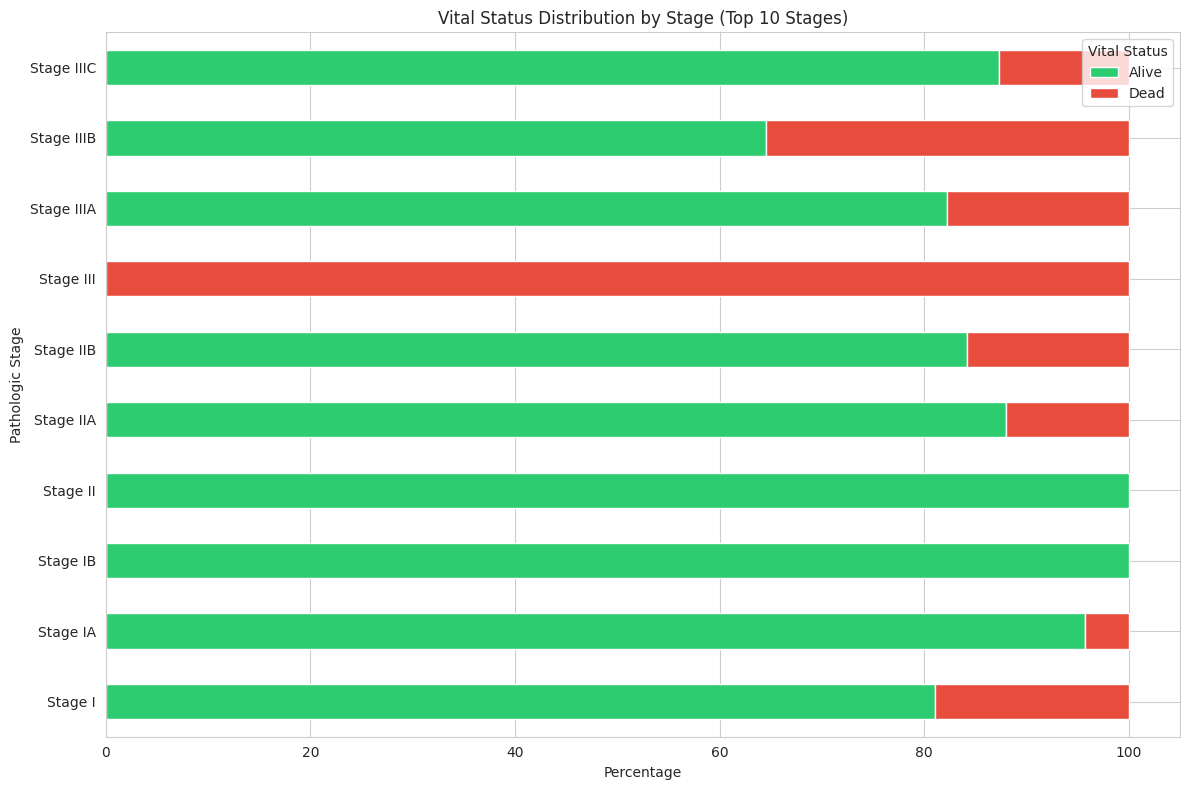

In [16]:
# Vital status by stage
if 'vital_status.demographic' in clinical.columns and 'ajcc_pathologic_stage.diagnoses' in clinical.columns:
    vital_stage_ct = pd.crosstab(
        clinical['ajcc_pathologic_stage.diagnoses'],
        clinical['vital_status.demographic'],
        normalize='index'
    ) * 100  # Convert to percentage

    print("\nVital Status by Stage (% within each stage):")
    print(vital_stage_ct.head(10).round(1))

    # Visualize
    vital_stage_ct.head(10).plot(kind='barh', stacked=True, figsize=(12, 8),
                                 color=['#2ecc71', '#e74c3c'])
    plt.xlabel('Percentage')
    plt.ylabel('Pathologic Stage')
    plt.title('Vital Status Distribution by Stage (Top 10 Stages)')
    plt.legend(title='Vital Status')
    plt.tight_layout()
    plt.show()

## Summary Statistics

In [17]:
# Overall summary
# Determine the patient/case ID column
patient_col = None
if 'case_id' in clinical.columns:
    patient_col = 'case_id'
elif 'sample' in clinical.columns:
    patient_col = 'sample'
elif 'patient_id' in clinical.columns:
    patient_col = 'patient_id'

unique_patients = clinical[patient_col].nunique() if patient_col else 'N/A'

summary = {
    'Metric': [
        'Total Samples',
        'Unique Patients',
        'Total Columns',
        'Demographic Columns',
        'Diagnosis Columns',
        'Treatment Columns',
        'Sample Columns',
    ],
    'Count': [
        len(clinical),
        unique_patients,
        len(clinical.columns),
        len([c for c in clinical.columns if 'demographic' in c]),
        len([c for c in clinical.columns if 'diagnoses' in c]),
        len([c for c in clinical.columns if 'treatment' in c.lower()]),
        len([c for c in clinical.columns if 'samples' in c]),
    ]
}

summary_df = pd.DataFrame(summary)
print("\n" + "="*50)
print("TCGA-BRCA Clinical Data Summary")
print("="*50)
print(summary_df.to_string(index=False))
print("="*50)
if patient_col:
    print(f"Patient ID column: {patient_col}")
else:
    print("Note: Could not identify patient ID column")


TCGA-BRCA Clinical Data Summary
             Metric  Count
      Total Samples   1257
    Unique Patients   1098
      Total Columns     89
Demographic Columns      9
  Diagnosis Columns     30
  Treatment Columns      8
     Sample Columns     15
Patient ID column: case_id


In [18]:
# Export summary for integration
# Determine the patient/case ID column
patient_col = None
if 'case_id' in clinical.columns:
    patient_col = 'case_id'
elif 'sample' in clinical.columns:
    patient_col = 'sample'
elif 'patient_id' in clinical.columns:
    patient_col = 'patient_id'

clinical_summary = {
    'total_samples': len(clinical),
    'unique_patients': clinical[patient_col].nunique() if patient_col else None,
    'patient_col': patient_col,
    'sample_types': clinical['sample_type.samples'].value_counts().to_dict() if 'sample_type.samples' in clinical.columns else {},
}

print("\nClinical data summary for integration:")
for key, value in clinical_summary.items():
    if key == 'sample_types':
        print(f"  {key}: {len(value)} types")
    else:
        print(f"  {key}: {value}")


Clinical data summary for integration:
  total_samples: 1257
  unique_patients: 1098
  patient_col: case_id
  sample_types: 3 types
